In [1]:
from sklearn.datasets import fetch_openml

electricity = fetch_openml(
    name="electricity", version=1, as_frame=True, parser="pandas"
)
df = electricity.frame

In [2]:
df["transfer"][:17_760].unique()

array([0.414912, 0.500526])

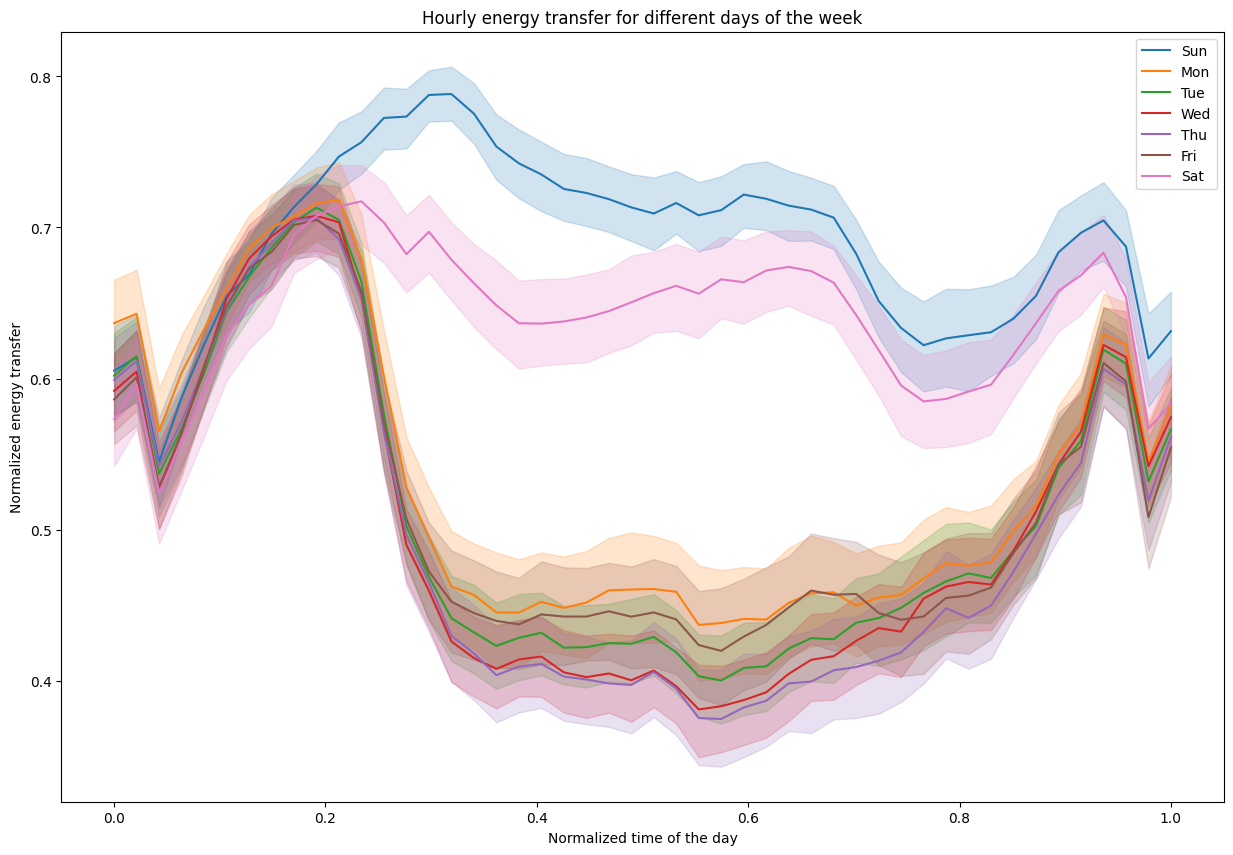

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df = electricity.frame.iloc[17_760:]
X = df.drop(columns=["transfer", "class"])
y = df["transfer"]

fig, ax = plt.subplots(figsize=(15, 10))
pointplot = sns.lineplot(x=df["period"], y=df["transfer"], hue=df["day"], ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.set(
    title="Hourly energy transfer for different days of the week",
    xlabel="Normalized time of the day",
    ylabel="Normalized energy transfer",
)
_ = ax.legend(handles, ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)

print(f"Training sample size: {X_train.shape[0]}")
print(f"Test sample size: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training sample size: 16531
Test sample size: 11021
Number of features: 7


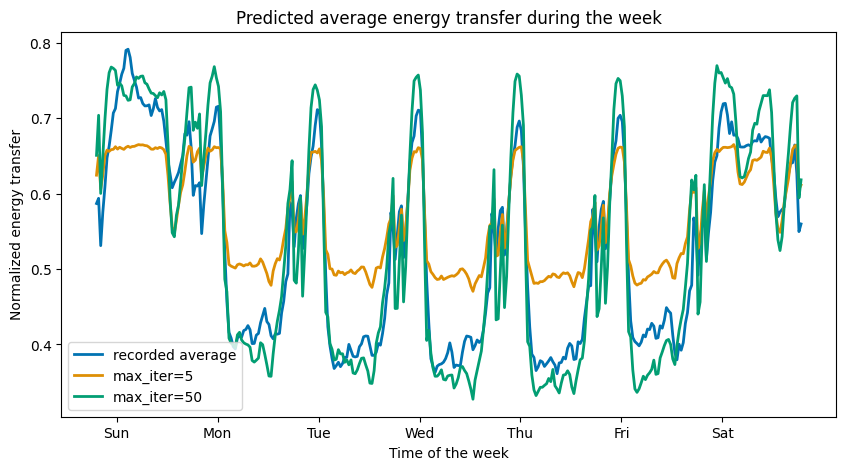

In [5]:
max_iter_list = [5, 50]
average_week_demand = (
    df.loc[X_test.index].groupby(["day", "period"], observed=False)["transfer"].mean()
)
colors = sns.color_palette("colorblind")
fig, ax = plt.subplots(figsize=(10, 5))
average_week_demand.plot(color=colors[0], label="recorded average", linewidth=2, ax=ax)

for idx, max_iter in enumerate(max_iter_list):
    hgbt = HistGradientBoostingRegressor(
        max_iter=max_iter, categorical_features=None, random_state=42
    )
    hgbt.fit(X_train, y_train)

    y_pred = hgbt.predict(X_test)
    prediction_df = df.loc[X_test.index].copy()
    prediction_df["y_pred"] = y_pred
    average_pred = prediction_df.groupby(["day", "period"], observed=False)[
        "y_pred"
    ].mean()
    average_pred.plot(
        color=colors[idx + 1], label=f"max_iter={max_iter}", linewidth=2, ax=ax
    )

ax.set(
    title="Predicted average energy transfer during the week",
    xticks=[(i + 0.2) * 48 for i in range(7)],
    xticklabels=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    xlabel="Time of the week",
    ylabel="Normalized energy transfer",
)
_ = ax.legend()

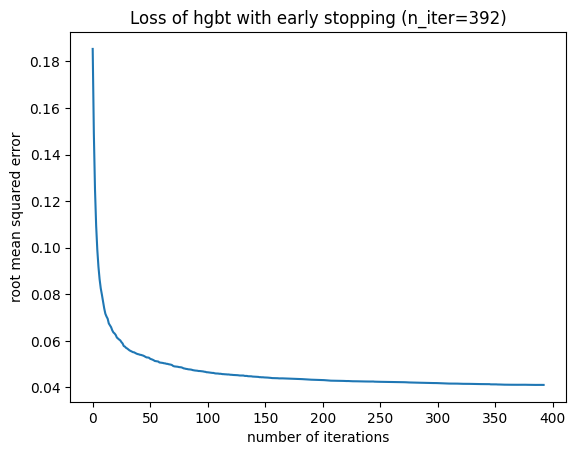

In [6]:
common_params = {
    "max_iter": 1_000,
    "learning_rate": 0.3,
    "validation_fraction": 0.2,
    "random_state": 42,
    "categorical_features": None,
    "scoring": "neg_root_mean_squared_error",
}

hgbt = HistGradientBoostingRegressor(early_stopping=True, **common_params)
hgbt.fit(X_train, y_train)

_, ax = plt.subplots()
plt.plot(-hgbt.validation_score_)
_ = ax.set(
    xlabel="number of iterations",
    ylabel="root mean squared error",
    title=f"Loss of hgbt with early stopping (n_iter={hgbt.n_iter_})",
)

In [7]:
import math

common_params["max_iter"] = math.ceil(hgbt.n_iter_ / 100) * 100
common_params["early_stopping"] = False
hgbt = HistGradientBoostingRegressor(**common_params)

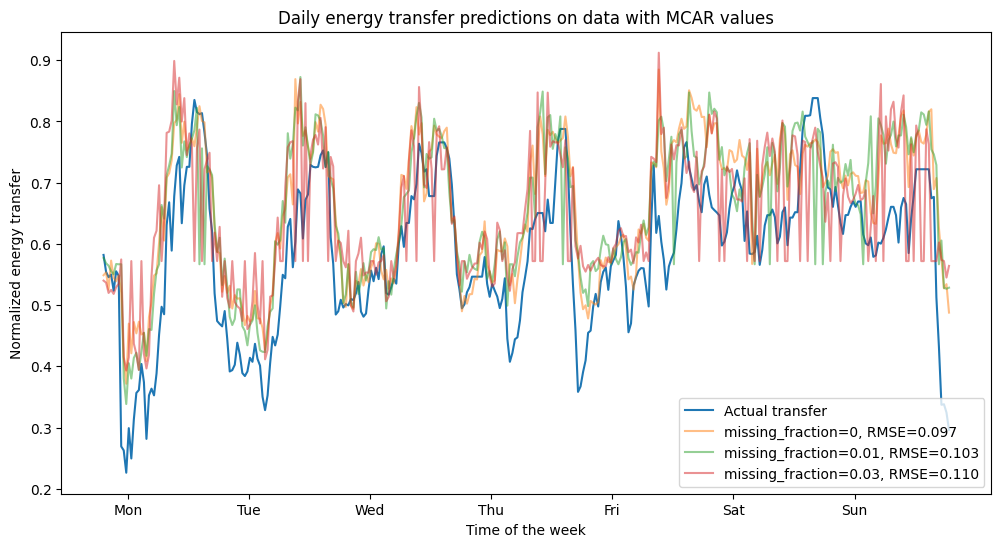

In [8]:
import numpy as np

from sklearn.metrics import root_mean_squared_error

rng = np.random.RandomState(42)
first_week = slice(0, 336)  # first week in the test set as 7 * 48 = 336
missing_fraction_list = [0, 0.01, 0.03]


def generate_missing_values(X, missing_fraction):
    total_cells = X.shape[0] * X.shape[1]
    num_missing_cells = int(total_cells * missing_fraction)
    row_indices = rng.choice(X.shape[0], num_missing_cells, replace=True)
    col_indices = rng.choice(X.shape[1], num_missing_cells, replace=True)
    X_missing = X.copy()
    X_missing.iloc[row_indices, col_indices] = np.nan
    return X_missing


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_test.values[first_week], label="Actual transfer")

for missing_fraction in missing_fraction_list:
    X_train_missing = generate_missing_values(X_train, missing_fraction)
    X_test_missing = generate_missing_values(X_test, missing_fraction)
    hgbt.fit(X_train_missing, y_train)
    y_pred = hgbt.predict(X_test_missing[first_week])
    rmse = root_mean_squared_error(y_test[first_week], y_pred)
    ax.plot(
        y_pred[first_week],
        label=f"missing_fraction={missing_fraction}, RMSE={rmse:.3f}",
        alpha=0.5,
    )
ax.set(
    title="Daily energy transfer predictions on data with MCAR values",
    xticks=[(i + 0.2) * 48 for i in range(7)],
    xticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel="Time of the week",
    ylabel="Normalized energy transfer",
)
_ = ax.legend(loc="lower right")

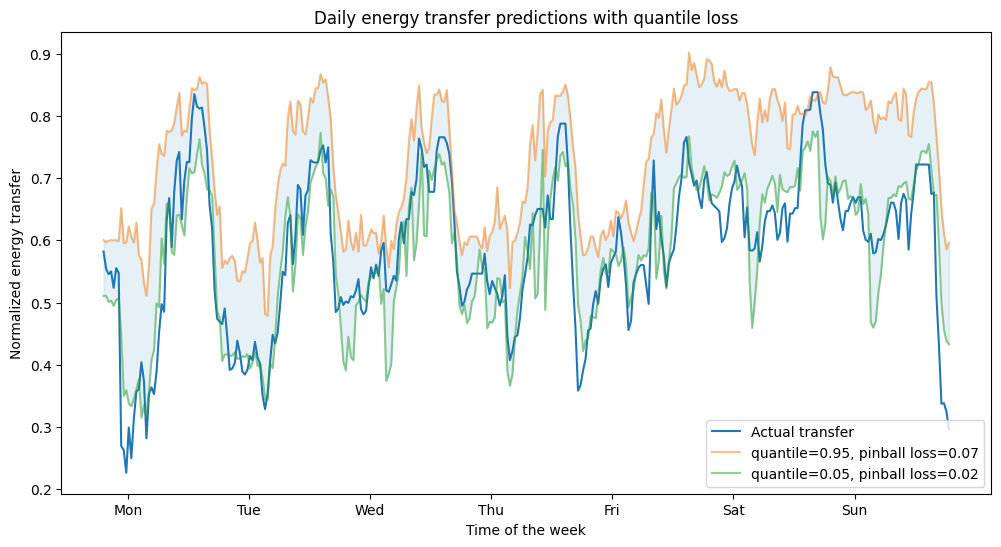

In [9]:
from sklearn.metrics import mean_pinball_loss

quantiles = [0.95, 0.05]
predictions = []

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_test.values[first_week], label="Actual transfer")

for quantile in quantiles:
    hgbt_quantile = HistGradientBoostingRegressor(
        loss="quantile", quantile=quantile, **common_params
    )
    hgbt_quantile.fit(X_train, y_train)
    y_pred = hgbt_quantile.predict(X_test[first_week])

    predictions.append(y_pred)
    score = mean_pinball_loss(y_test[first_week], y_pred)
    ax.plot(
        y_pred[first_week],
        label=f"quantile={quantile}, pinball loss={score:.2f}",
        alpha=0.5,
    )

ax.fill_between(
    range(len(predictions[0][first_week])),
    predictions[0][first_week],
    predictions[1][first_week],
    color=colors[0],
    alpha=0.1,
)
ax.set(
    title="Daily energy transfer predictions with quantile loss",
    xticks=[(i + 0.2) * 48 for i in range(7)],
    xticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel="Time of the week",
    ylabel="Normalized energy transfer",
)
_ = ax.legend(loc="lower right")

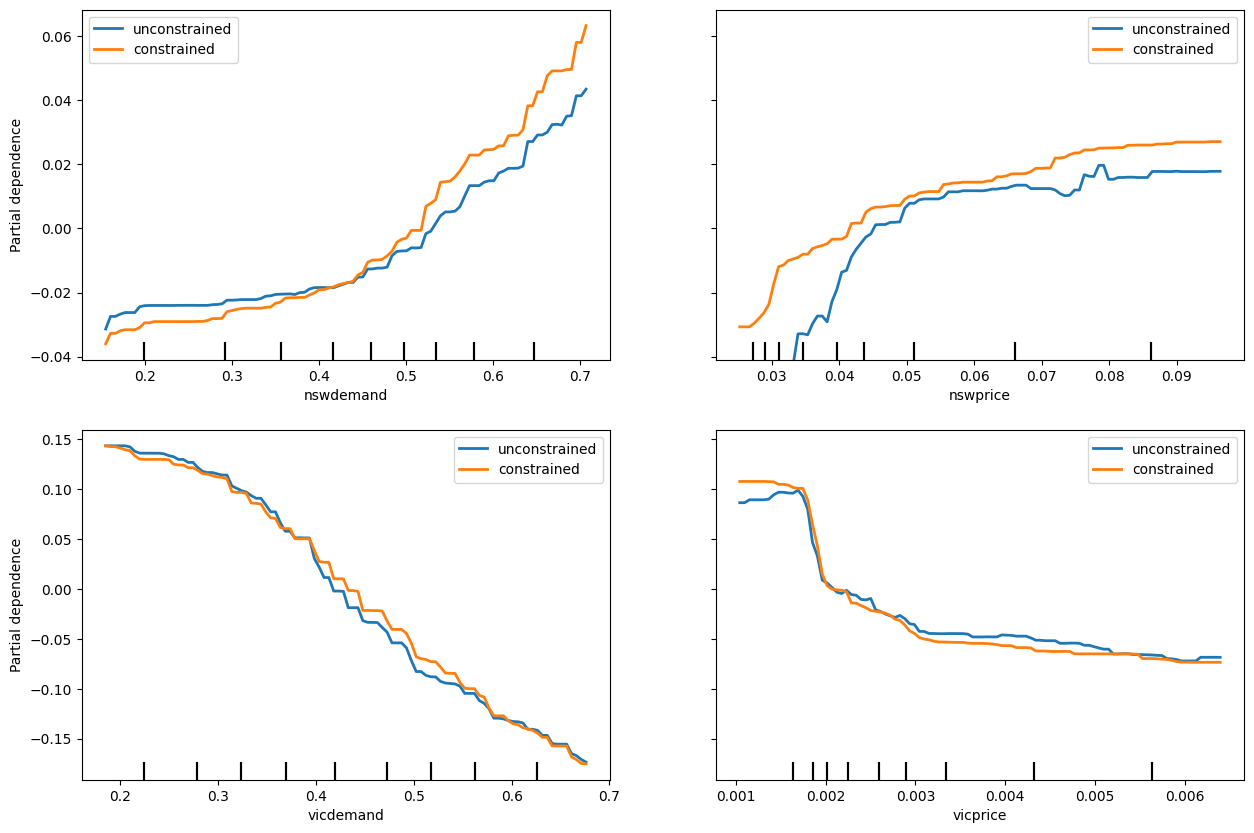

In [10]:
from sklearn.inspection import PartialDependenceDisplay

monotonic_cst = {
    "date": 0,
    "day": 0,
    "period": 0,
    "nswdemand": 1,
    "nswprice": 1,
    "vicdemand": -1,
    "vicprice": -1,
}
hgbt_no_cst = HistGradientBoostingRegressor(
    categorical_features=None, random_state=42
).fit(X, y)
hgbt_cst = HistGradientBoostingRegressor(
    monotonic_cst=monotonic_cst, categorical_features=None, random_state=42
).fit(X, y)

fig, ax = plt.subplots(nrows=2, figsize=(15, 10))
disp = PartialDependenceDisplay.from_estimator(
    hgbt_no_cst,
    X,
    features=["nswdemand", "nswprice"],
    line_kw={"linewidth": 2, "label": "unconstrained", "color": "tab:blue"},
    ax=ax[0],
)
PartialDependenceDisplay.from_estimator(
    hgbt_cst,
    X,
    features=["nswdemand", "nswprice"],
    line_kw={"linewidth": 2, "label": "constrained", "color": "tab:orange"},
    ax=disp.axes_,
)
disp = PartialDependenceDisplay.from_estimator(
    hgbt_no_cst,
    X,
    features=["vicdemand", "vicprice"],
    line_kw={"linewidth": 2, "label": "unconstrained", "color": "tab:blue"},
    ax=ax[1],
)
PartialDependenceDisplay.from_estimator(
    hgbt_cst,
    X,
    features=["vicdemand", "vicprice"],
    line_kw={"linewidth": 2, "label": "constrained", "color": "tab:orange"},
    ax=disp.axes_,
)
_ = plt.legend()

In [11]:
from sklearn.metrics import make_scorer, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_validate

ts_cv = TimeSeriesSplit(n_splits=5, gap=48, test_size=336)  # a week has 336 samples
scorer = make_scorer(root_mean_squared_error)

cv_results = cross_validate(hgbt_no_cst, X, y, cv=ts_cv, scoring=scorer)
rmse = cv_results["test_score"]
print(f"RMSE without constraints = {rmse.mean():.3f} +/- {rmse.std():.3f}")

cv_results = cross_validate(hgbt_cst, X, y, cv=ts_cv, scoring=scorer)
rmse = cv_results["test_score"]
print(f"RMSE with constraints    = {rmse.mean():.3f} +/- {rmse.std():.3f}")

RMSE without constraints = 0.103 +/- 0.030
RMSE with constraints    = 0.107 +/- 0.034
